# Task 3: Transformer manual para forecasting

## 1. Preparación de datos

In [8]:
import ssl
import urllib.error
import urllib.request
from pathlib import Path

import certifi
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)
print(f'PyTorch: {torch.__version__}')

PyTorch: 2.13.0+cpu


In [9]:
URL = (
    'https://raw.githubusercontent.com/zhouhaoyi/'
    'ETDataset/main/ETT-small/ETTh1.csv'
)
DATA_PATH = Path('ETTh1.csv')

if not DATA_PATH.exists():
    try:
        urllib.request.urlretrieve(URL, DATA_PATH)
    except urllib.error.URLError as error:
        if DATA_PATH.exists():
            DATA_PATH.unlink()
        ssl_context = ssl.create_default_context(cafile=certifi.where())
        with urllib.request.urlopen(URL, context=ssl_context) as response:
            DATA_PATH.write_bytes(response.read())
        print(f'La descarga estándar falló ({error.reason}); se usó certifi.')

data = np.genfromtxt(DATA_PATH, delimiter=',', skip_header=1)
OT = data[:, -1].astype(np.float32)
OT_tensor = torch.from_numpy(OT)
mu = OT_tensor.mean()
sigma = OT_tensor.std(correction=0)
OT_norm = (OT_tensor - mu) / sigma

T = OT_norm.numel()
train_end = int(0.60 * T)
val_end = int(0.80 * T)
OT_train = OT_norm[:train_end].clone()
OT_val = OT_norm[train_end:val_end].clone()
OT_test = OT_norm[val_end:].clone()

print(f'Train={OT_train.shape}, val={OT_val.shape}, test={OT_test.shape}')

Train=torch.Size([10452]), val=torch.Size([3484]), test=torch.Size([3484])


In [10]:
def make_windows(series: torch.Tensor, L: int, H: int):
    windows = series.unfold(0, L + H, 1)
    return windows[:, :L].contiguous(), windows[:, -1].contiguous()

L = 96
X_tr_24, y_tr_24 = make_windows(OT_train, L, 24)
X_vl_24, y_vl_24 = make_windows(OT_val, L, 24)
X_ts_24, y_ts_24 = make_windows(OT_test, L, 24)
X_tr_48, y_tr_48 = make_windows(OT_train, L, 48)
X_vl_48, y_vl_48 = make_windows(OT_val, L, 48)
X_ts_48, y_ts_48 = make_windows(OT_test, L, 48)

naive_mae = torch.abs(y_vl_24 - X_vl_24[:, -1]).mean().item()
print(f'Naive MAE H=24: {naive_mae:.4f}')

Naive MAE H=24: 0.1996


# Task 3.1: Positional encoding

## 1. `make_pe`

$$\mathrm{PE}(t, 2i) = \sin\left(\frac{t}{10000^{2i/d_{model}}}\right), \qquad \mathrm{PE}(t, 2i+1) = \cos\left(\frac{t}{10000^{2i/d_{model}}}\right)$$

In [11]:
def make_pe(max_len, d_model):
    t = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
    two_i = torch.arange(0, d_model, 2, dtype=torch.float32)
    angles = t / torch.pow(10000.0, two_i / d_model)

    pe = torch.zeros(max_len, d_model)
    pe[:, 0::2] = torch.sin(angles)
    pe[:, 1::2] = torch.cos(angles[:, :d_model // 2])
    return pe

In [12]:
_pe = make_pe(96, 32)

assert _pe.shape == (96, 32), f'Forma incorrecta: {_pe.shape}'
assert not _pe.requires_grad, 'El positional encoding no debe ser aprendible'
assert torch.allclose(_pe[0, 0::2], torch.zeros(16)) and torch.allclose(_pe[0, 1::2], torch.ones(16))
assert torch.isclose(_pe[5, 2], torch.sin(torch.tensor(5 / 10000 ** (2 / 32))))
assert torch.isclose(_pe[5, 3], torch.cos(torch.tensor(5 / 10000 ** (2 / 32))))
assert make_pe(10, 7).shape == (10, 7)

print(f'PE shape: {tuple(_pe.shape)}, requires_grad={_pe.requires_grad}')

PE shape: (96, 32), requires_grad=False


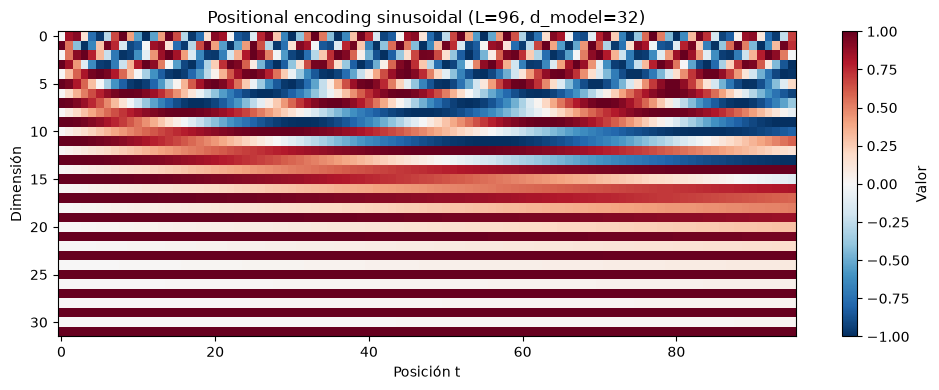

In [13]:
plt.figure(figsize=(10, 4))
plt.imshow(_pe.T.numpy(), aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(label='Valor')
plt.xlabel('Posición t')
plt.ylabel('Dimensión')
plt.title('Positional encoding sinusoidal (L=96, d_model=32)')
plt.tight_layout()
plt.show()

## 2. Proyección de la entrada a $\mathbb{R}^{d_{model}}$

Cada escalar $x_t$ se proyecta con `nn.Linear(1, d_model)` y luego se suma el positional encoding. Esta misma operación es el primer paso de `TransformerForecaster.forward` (Task 3.2).

In [14]:
_input_proj = nn.Linear(1, 32)
_x = X_tr_24[:4]
_embedded = _input_proj(_x.unsqueeze(-1)) + _pe[:L]

assert _embedded.shape == (4, L, 32), f'Forma incorrecta: {_embedded.shape}'
print(f'x: {tuple(_x.shape)} -> input_proj + PE: {tuple(_embedded.shape)}')

x: (4, 96) -> input_proj + PE: (4, 96, 32)


# Task 3.2: `TransformerForecaster`

Encoder de una capa implementado con tensores: multi-head self-attention, Add & Norm, feed-forward y Add & Norm. La predicción se lee de la posición 0, que actúa como token CLS.

In [15]:
class TransformerForecaster(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, L):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.L = L
        assert self.d_k * n_heads == d_model, 'd_model debe ser divisible por n_heads'

        self.input_proj = nn.Linear(1, d_model)
        self.register_buffer('PE', make_pe(L, d_model))

        self.WQ = nn.Parameter(torch.empty(d_model, d_model))
        self.WK = nn.Parameter(torch.empty(d_model, d_model))
        self.WV = nn.Parameter(torch.empty(d_model, d_model))
        self.WO = nn.Parameter(torch.empty(d_model, d_model))

        self.W1 = nn.Parameter(torch.empty(d_model, d_ff))
        self.b1 = nn.Parameter(torch.zeros(d_ff))
        self.W2 = nn.Parameter(torch.empty(d_ff, d_model))
        self.b2 = nn.Parameter(torch.zeros(d_model))

        self.gamma1 = nn.Parameter(torch.ones(d_model))
        self.beta1 = nn.Parameter(torch.zeros(d_model))
        self.gamma2 = nn.Parameter(torch.ones(d_model))
        self.beta2 = nn.Parameter(torch.zeros(d_model))

        self.W_out = nn.Linear(d_model, 1)

        for W in (self.WQ, self.WK, self.WV, self.WO, self.W1, self.W2):
            nn.init.xavier_uniform_(W)

    def layer_norm(self, x, gamma, beta, eps=1e-5):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        return gamma * (x - mean) / torch.sqrt(var + eps) + beta

    def multi_head_attention(self, x):
        B, L, _ = x.shape

        Q = x @ self.WQ
        K = x @ self.WK
        V = x @ self.WV

        Q = Q.reshape(B, L, self.n_heads, self.d_k).transpose(1, 2)
        K = K.reshape(B, L, self.n_heads, self.d_k).transpose(1, 2)
        V = V.reshape(B, L, self.n_heads, self.d_k).transpose(1, 2)

        scores = Q @ K.transpose(-2, -1) / self.d_k ** 0.5
        attn_w = torch.softmax(scores, dim=-1)
        out = attn_w @ V

        out = out.transpose(1, 2).reshape(B, L, self.d_model)
        return out @ self.WO, attn_w

    def feed_forward(self, x):
        return torch.relu(x @ self.W1 + self.b1) @ self.W2 + self.b2

    def forward(self, x, return_attn=False):
        L = x.shape[1]
        x = self.input_proj(x.unsqueeze(-1)) + self.PE[:L]

        att_out, attn_w = self.multi_head_attention(x)
        x = self.layer_norm(x + att_out, self.gamma1, self.beta1)

        ff_out = self.feed_forward(x)
        x = self.layer_norm(x + ff_out, self.gamma2, self.beta2)

        pred = self.W_out(x[:, 0, :]).squeeze(-1)
        if return_attn:
            return pred, attn_w
        return pred

## Verificación de componentes

In [16]:
torch.manual_seed(0)
_trf = TransformerForecaster(d_model=32, n_heads=2, d_ff=64, L=96)
_x = torch.randn(4, 96)

_pred, _attn = _trf(_x, return_attn=True)
assert _pred.shape == (4,), f'pred shape incorrecto: {_pred.shape}'
assert _attn.shape == (4, 2, 96, 96), f'attn shape incorrecto: {_attn.shape}'
assert torch.allclose(_attn.sum(-1), torch.ones(4, 2, 96), atol=1e-5)
assert _trf(_x).shape == (4,)

_h = torch.randn(4, 96, 32)
_ln_ref = F.layer_norm(_h, (32,), _trf.gamma1, _trf.beta1, eps=1e-5)
assert torch.allclose(_trf.layer_norm(_h, _trf.gamma1, _trf.beta1), _ln_ref, atol=1e-5), \
    'layer_norm no coincide con la referencia'

assert 'PE' in dict(_trf.named_buffers()) and 'PE' not in dict(_trf.named_parameters()), \
    'El PE debe ser un buffer no aprendible'

_n_params = sum(p.numel() for p in _trf.parameters())
print(f'pred: {tuple(_pred.shape)}, attn_w: {tuple(_attn.shape)}')
print(f'Parámetros entrenables: {_n_params}')

pred: (4,), attn_w: (4, 2, 96, 96)
Parámetros entrenables: 8513
